In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch

In [3]:
# Random Seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [4]:
dataset_path = "/content/drive/MyDrive/Day-04/rps"

print(dataset_path)

/content/drive/MyDrive/Day-04/rps


In [5]:
# Check dataset
print(os.listdir(dataset_path))

['paper', 'rock', 'scissors']


In [6]:
# Class names
classes = os.listdir(dataset_path)
print(classes)

['paper', 'rock', 'scissors']


# Count Images

In [7]:
# Count images in each class
for folder in classes:

    folder_path = os.path.join(dataset_path, folder)

    total = len(os.listdir(folder_path))

    print(folder, ":", total)

paper : 840
rock : 840
scissors : 840


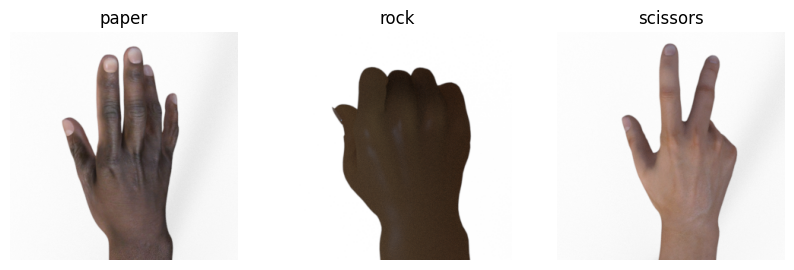

In [10]:
# Show one image from each class
plt.figure(figsize=(10,4))
for i, folder in enumerate(classes):
    folder_path = os.path.join(dataset_path, folder)
    image_name = random.choice(os.listdir(folder_path))
    image_path = os.path.join(folder_path, image_name)
    image = Image.open(image_path)

    plt.subplot(1,3,i+1)
    plt.imshow(image)
    plt.title(folder)
    plt.axis("off")

plt.show()

In [9]:
# Check GPU
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device :", device)

Device : cuda


# Data Preprocessing

In [11]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

## Training Transform

In [12]:
# Training image preprocessing
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )

])

## Validation & Test Transform

In [13]:
# Validation and Test preprocessing
test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )

])

## Load Dataset

In [17]:
# Load dataset
full_dataset = datasets.ImageFolder(
    root=dataset_path,
    transform=train_transform
)
print("Total Images :", len(full_dataset))

Total Images : 2520


## Split Dataset

In [18]:
# Split dataset

train_size = int(0.70 * len(full_dataset))

val_size = int(0.15 * len(full_dataset))

test_size = len(full_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(

    full_dataset,

    [train_size, val_size, test_size]

)

print("Train :", len(train_dataset))
print("Validation :", len(val_dataset))
print("Test :", len(test_dataset))

Train : 1764
Validation : 378
Test : 378


## Change Validation and Test Transform

In [19]:
# Create dataset again
full_dataset_train = datasets.ImageFolder(
    dataset_path,
    transform=train_transform
)
full_dataset_test = datasets.ImageFolder(
    dataset_path,
    transform=test_transform
)

In [20]:
# Apply transforms
train_dataset.dataset = full_dataset_train
val_dataset.dataset = full_dataset_test
test_dataset.dataset = full_dataset_test

## DataLoader

In [21]:
# Batch size

batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True

)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False

)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False

)

In [22]:
# Check one batch

images, labels = next(iter(train_loader))
print(images.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


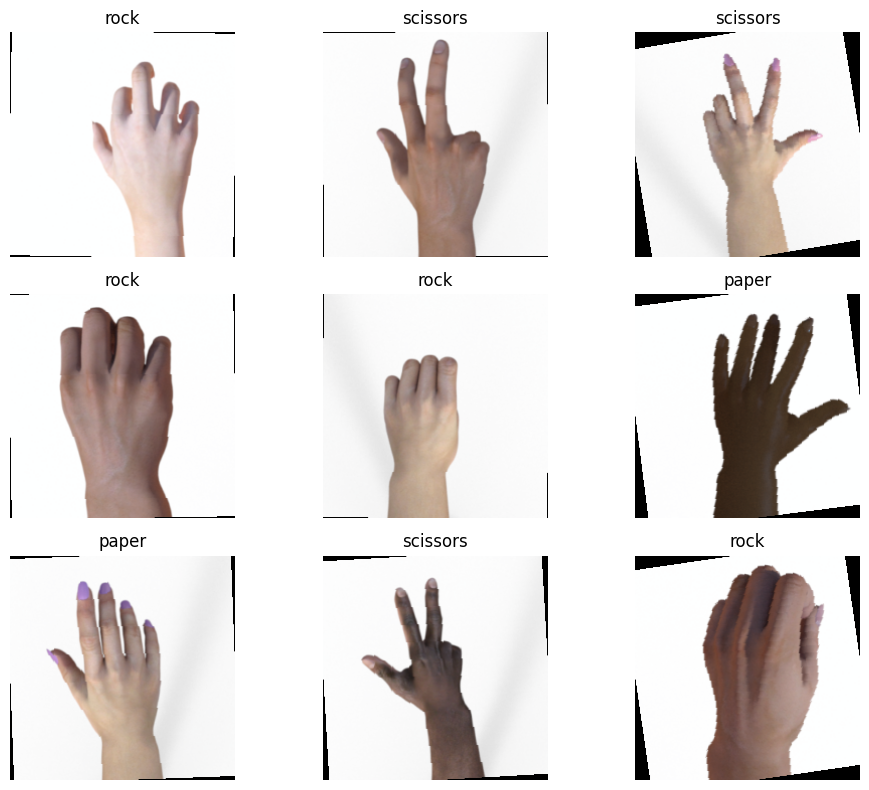

In [24]:
# Show training images

plt.figure(figsize=(10,8))
for i in range(9):
    image = images[i].permute(1,2,0).numpy()
    image = image * [0.229,0.224,0.225] + [0.485,0.456,0.406]
    image = np.clip(image,0,1)
    plt.subplot(3,3,i+1)
    plt.imshow(image)
    plt.title(classes[labels[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

# Build the Model

In [25]:
# Import libraries

import torch.nn as nn
from torchvision import models

## Load MobileNetV3

In [26]:
# Load pretrained model

model = models.mobilenet_v3_small(weights="DEFAULT")

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 177MB/s]


## View the Classifier

In [27]:
# View classifier

print(model.classifier)

Sequential(
  (0): Linear(in_features=576, out_features=1024, bias=True)
  (1): Hardswish()
  (2): Dropout(p=0.2, inplace=True)
  (3): Linear(in_features=1024, out_features=1000, bias=True)
)


In [28]:
# Replace output layer

model.classifier[3] = nn.Linear(
    model.classifier[3].in_features,
    3
)

## Freeze the Feature Extractor

In [29]:
for param in model.features.parameters():
    param.requires_grad = False

In [30]:
# Move model to GPU

model = model.to(device)

In [31]:
print(model)

MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): SqueezeExcitation(
          (avgpool): AdaptiveAvgPool2d(output_size=1)
          (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
          (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
          (activation): ReLU()
          (scale_activation): Hardsigmoid()
        )
        (2): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), 

## Count Trainable Parameters

In [32]:
# Count trainable parameters

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Trainable Parameters :", trainable)

Trainable Parameters : 593923


## Verify Output Shape

In [34]:
# Test model

sample = torch.randn(1,3,224,224).to(device)
output = model(sample)
print(output.shape)

torch.Size([1, 3])


# Train the Model

In [35]:
# Loss function

criterion = nn.CrossEntropyLoss()

## Optimizer

In [37]:
# Optimizer

optimizer = torch.optim.AdamW(
    model.classifier.parameters(),
    lr=0.001,
    weight_decay=1e-4

)

## Learning Rate Scheduler

In [39]:
# Reduce learning rate

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.1,
    patience=2
)

## Early Stopping Variables

In [48]:
# Early stopping

best_loss = float("inf")
patience = 5
counter = 0
epochs = 30

## Store Results

In [49]:
from tqdm import tqdm

In [50]:
def train_one_epoch(model, loader):

    model.train()

    total_loss = 0
    correct = 0

    progress = tqdm(loader, desc="Training", leave=False)

    for images, labels in progress:
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        predicted = outputs.argmax(1)
        correct += (predicted == labels).sum().item()
        progress.set_postfix(loss=loss.item())

    avg_loss = total_loss / len(loader)

    accuracy = 100 * correct / len(loader.dataset)

    return avg_loss, accuracy

In [51]:
def validate_one_epoch(model, loader):

    model.eval()

    total_loss = 0
    correct = 0

    with torch.no_grad():

        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            predicted = outputs.argmax(1)
            correct += (predicted == labels).sum().item()

    avg_loss = total_loss / len(loader)

    accuracy = 100 * correct / len(loader.dataset)

    return avg_loss, accuracy

In [53]:
for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}/{epochs}")

    train_loss, train_acc = train_one_epoch(model, train_loader)
    val_loss, val_acc = validate_one_epoch(model, val_loader)
    scheduler.step(val_loss)

    print(f"Train Loss : {train_loss:.4f}")
    print(f"Train Accuracy : {train_acc:.2f}%")

    print(f"Validation Loss : {val_loss:.4f}")
    print(f"Validation Accuracy : {val_acc:.2f}%")

    if val_loss < best_loss:
        best_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), "model.pth")
        print("Best model saved.")
    else:
        counter += 1
        print(f"Early Stopping Counter : {counter}/{patience}")
    if counter >= patience:
        print("Early stopping...")
        break


Epoch 1/30


Train Loss : 0.0887
Train Accuracy : 97.56%
Validation Loss : 0.3670
Validation Accuracy : 84.39%
Best model saved.

Epoch 2/30


Train Loss : 0.0800
Train Accuracy : 97.45%
Validation Loss : 0.1094
Validation Accuracy : 94.71%
Best model saved.

Epoch 3/30


Train Loss : 0.0584
Train Accuracy : 97.85%
Validation Loss : 0.0756
Validation Accuracy : 97.62%
Best model saved.

Epoch 4/30


Train Loss : 0.0386
Train Accuracy : 98.58%
Validation Loss : 0.0157
Validation Accuracy : 99.47%
Best model saved.

Epoch 5/30


...

Train Loss : 0.0079
Train Accuracy : 99.89%
Validation Loss : 0.0025
Validation Accuracy : 100.00%
Early Stopping Counter : 1/5

Epoch 15/30


Train Loss : 0.0151
Train Accuracy : 99.55%
Validation Loss : 0.0027
Validation Accuracy : 100.00%
Early Stopping Counter : 2/5

Epoch 16/30


Train Loss : 0.0071
Train Accuracy : 99.83%
Validation Loss : 0.0025
Validation Accuracy : 100.00%
Early Stopping Counter : 3/5

Epoch 17/30


Train Loss : 0.0136
Train Accuracy : 99.83%
Validation Loss : 0.0025
Validation Accuracy : 100.00%
Early Stopping Counter : 4/5

Epoch 18/30


Train Loss : 0.0116
Train Accuracy : 99.72%
Validation Loss : 0.0025
Validation Accuracy : 100.00%
Early Stopping Counter : 5/5
Early stopping...


In [54]:
# Load best model

model.load_state_dict(torch.load("model.pth"))

<All keys matched successfully>

In [55]:
# Image preprocessing

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [56]:
image_path = "/content/drive/MyDrive/Day-04/rps/rock/rock01-000.png"

In [57]:
# Class names

classes = ['paper', 'rock', 'scissors']

# Actual label

actual = image_path.split("/")[-2]

# Read image

image = Image.open(image_path).convert("RGB")

# Keep original image

display_image = image

# Preprocess

image = transform(image)

image = image.unsqueeze(0).to(device)

# Prediction

with torch.no_grad():

    output = model(image)

    probability = torch.softmax(output, dim=1)

    confidence, prediction = torch.max(probability,1)

predicted = classes[prediction.item()]
confidence = confidence.item() * 100

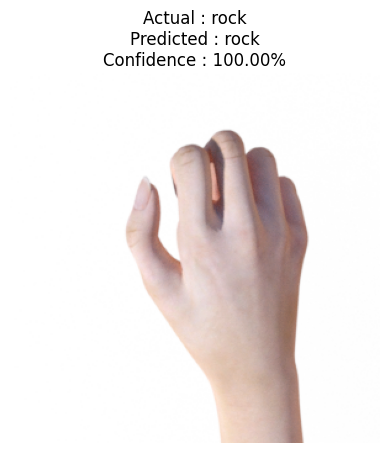

In [58]:
plt.imshow(display_image)

plt.title(
    f"Actual : {actual}\n"
    f"Predicted : {predicted}\n"
    f"Confidence : {confidence:.2f}%"
)

plt.axis("off")

plt.show()

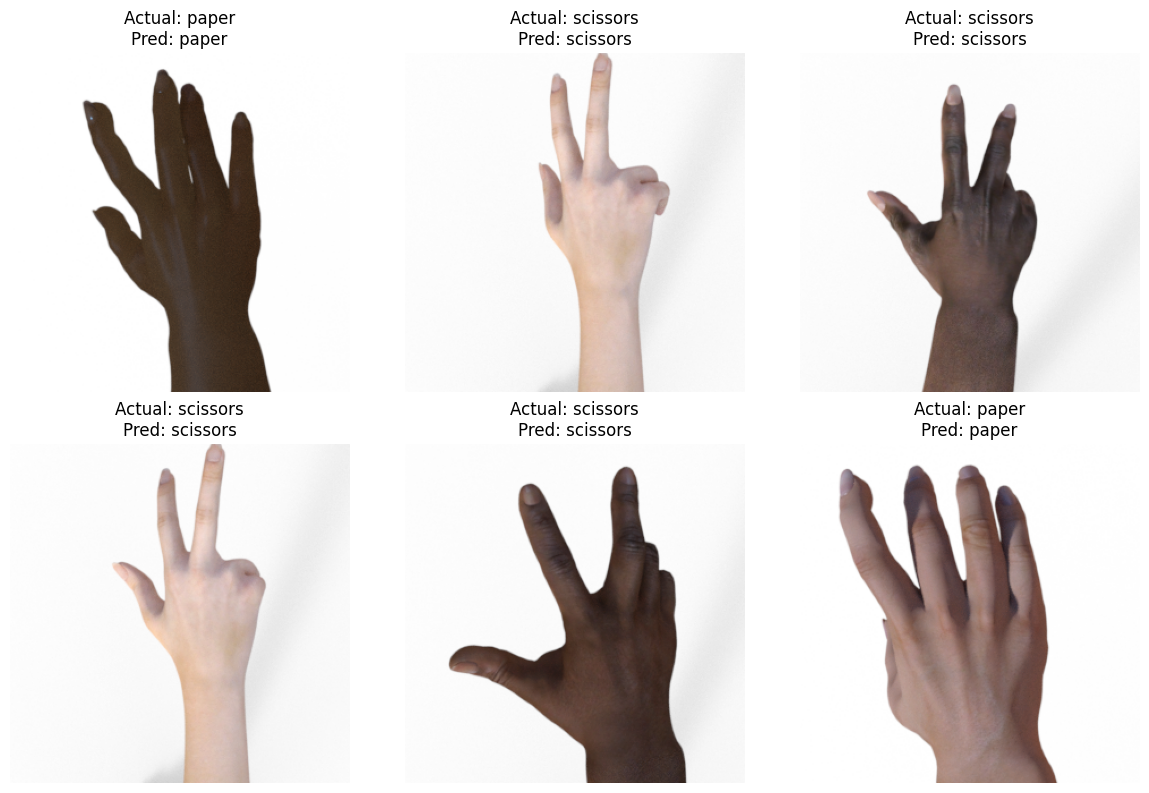

In [59]:
import random
import os

classes = ['paper', 'rock', 'scissors']

plt.figure(figsize=(12,8))

for i in range(6):

    folder = random.choice(classes)

    folder_path = os.path.join(dataset_path, folder)

    image_name = random.choice(os.listdir(folder_path))

    image_path = os.path.join(folder_path, image_name)

    image = Image.open(image_path).convert("RGB")
    display = image

    img = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(img)
        prob = torch.softmax(output, dim=1)
        confidence, pred = torch.max(prob,1)

    predicted = classes[pred.item()]

    plt.subplot(2,3,i+1)
    plt.imshow(display)
    plt.title(f"Actual: {folder}\nPred: {predicted}")
    plt.axis("off")

plt.tight_layout()
plt.show()